> 📖 Book: [ch02 – Eigen/SVD](../../.claude/skills/ml-knowledge/chapters/ch02-linear-algebra-eigen-svd.md), [ch03 – Least squares, pseudo-inverse, Tikhonov](../../.claude/skills/ml-knowledge/chapters/ch03-least-squares-pseudoinverse-tikhonov.md) · Prev: [02](02_supervised_learning.ipynb) · Next: [04 SVD](04_svd.ipynb)

# The Linear Inversion Problem

The **linear inversion problem** is present in many scientific and engineering fields. It refers to the process of using observed data ($b$) to infer unknown parameters or states ($x$) that characterize a linear system to estimate data that is not direcly observed. To solve a linear inversion problem it needs to be **well-posed**.


## What is a "Well-Posed Problem"?

This goes back to **Hadamard’s definition (1902)**.
A problem is **well-posed** if it satisfies **three conditions**:

1. **Existence**
   A solution $x$ exists.
   (There *is* some $x$ that explains the data.)

2. **Uniqueness**
   The solution is unique.
   (Only *one* $x$ explains the data — no ambiguity.)

3. **Stability**
   The solution depends continuously on the data $b$.
   (If you perturb $b$ a little, the solution $x$ changes only a little.)

Example: Solving a simple linear system with a well-conditioned matrix $A$.
Every small change in $b$ leads to a small change in $x$.

If **any** of the above three conditions fail, the problem is **ill-posed**.


**Typical cases:**

1. **No solution (inconsistency)**
   Example: Overdetermined system with noisy data ($Ax \neq b$ exactly).

2. **Non-unique solution**
   Example: Underdetermined system (more unknowns than equations).
   Infinitely many $x$ satisfy $Ax=b$.

3. **Instability (sensitive to noise)**
   Example: If $A$ is nearly singular (ill-conditioned), then a tiny noise in $b$ causes huge errors in $x$.
   This happens a lot in imaging, geophysics, and ML.

 ### Intuition with Examples

* **Well-posed**:
  Measuring the length of a rod with a good ruler.
  → The length exists, is unique, and small measurement noise gives small error.

* **Ill-posed**:
  Trying to sharpen a very blurry photo.
  → Many possible sharp images could explain the blurry one (non-unique), and tiny noise in the pixels can drastically change the reconstructed image (unstable).

**Why It Matters**

* Well-posed problems: you can safely solve them with direct/iterative solvers.
* Ill-posed problems: need **regularization** (like Tikhonov, ridge regression, truncated SVD, etc.) to stabilize the solution.

## Mathematical Formulation

The linear inversion problem is generally presented as solving a system of linear equations of the form:

$$ Ax = b $$

where the goal is to determine an unknown vector $x$ from observed data $b$ and a known matrix $A$.

Here:

* $A \in \mathbb{R}^{m \times n}$ is a matrix (possibly tall, wide, square, or ill-conditioned),
* $x \in \mathbb{R}^n$ is the unknown,
* $b \in \mathbb{R}^m$ is the data vector.

Scenarios vary based on the dimensions of $A$:

* If $m = n$ and $A$ is full rank → classical linear system.
* If $m > n$ (overdetermined) → least squares problem (common in ML).
* If $m < n$ (underdetermined) → infinitely many solutions; often regularization is needed.

## Applications

Here's a list of **practical real-world examples** where **linear inversion problems** emerge:

### Machine Learning / Data Science

* **Linear Regression**
  Fit parameters $w$ by solving $(X^TX)w = X^Ty$.
* **Ridge Regression / Tikhonov Regularization**
  Solve $(X^TX + \lambda I)w = X^Ty$.
* **PCA (Principal Component Analysis)**
  Eigenvalue problem: solve $X^TXv = \lambda v$.
* **Collaborative Filtering / Recommender Systems**
  Matrix factorization often reduces to least squares subproblems.
* **Kernel methods (SVM, Gaussian processes)**
  Need to solve $K\alpha = y$, where $K$ is huge → iterative methods + preconditioning.
* **Neural networks**
  Optimization methods (like SGD) can be seen as iterative solvers for nonlinear extensions of $Ax=b$.

### Signal Processing & Imaging

* **Deconvolution (blurred images, audio signals)**
  Recover true signal $x$ from blurred/filtered version $b = Ax$.
* **Tomography (CT, MRI, PET scans)**
  Reconstruct internal images of the body from projection data: $Ax = b$.
* **Seismic Imaging (Oil exploration, earthquake studies)**
  Infer underground structure from surface measurements.
* **Inverse Filtering in Audio**
  Remove reverberation: recover original signal from room impulse response.

### Physics & Engineering

* **Finite Difference / Finite Element Methods**
  Discretizing PDEs (heat, wave, elasticity equations) → linear systems $Ax = b$.
* **Circuit Analysis**
  Kirchhoff's laws lead to linear systems for voltages/currents.
* **Structural Engineering**
  Load-displacement relationships: stiffness matrix $K u = f$.
* **Control Theory**
  State estimation problems reduce to linear system solutions.

### Computer Science & Graphs

* **PageRank (Google Search)**
  Solve $(I - \alpha P)x = (1-\alpha)v$.
* **Markov Chains**
  Stationary distribution solves $x = P^Tx$.
* **Graph Laplacian Systems**
  Used in spectral clustering, semi-supervised learning.

### Geosciences & Remote Sensing

* **Geophysical Inversion**
  Estimate earth's density/conductivity from surface measurements.
* **Satellite Remote Sensing**
  Recover surface reflectance or temperature from observed radiances.

### Finance & Economics

* **Portfolio Optimization (Quadratic)**
  Involves solving linear systems from first-order conditions.
* **Input-Output Models (Leontief economics)**
  Solve $(I-A)x = d$ for production levels.
* **Risk Models**
  Linear factor models reduce to least squares problems.

### Medical Applications

* **EEG/MEG Source Localization**
  Infer brain sources from scalp measurements: $Ax = b$.
* **Breast Impedance Tomography**
  Estimate tissue properties from bio-impedance data.

## Methods to Solve $Ax = b$

### Direct Methods

These try to solve the system in a finite number of algebraic operations (ignoring numerical round-off).

**Gaussian Elimination**

* Factorize $A$ into $LU$ (lower and upper triangular).
* Solve $LUx = b$.
* Complexity: $O(n^3)$.
* Stable in practice if pivoting is used (partial pivoting → $PA = LU$).

**Cholesky Decomposition**

* If $A$ is symmetric positive definite (SPD): $A = LL^T$.
* Very efficient and stable, complexity $O(n^3/3)$.
* Common in least squares and ML (covariance matrices, kernel matrices).

**QR Decomposition**

* For least squares problems: factor $A = QR$, then solve $Rx = Q^Tb$.
* Numerically stable.
* Complexity $O(mn^2)$ if $m \gg n$.
* Very important in ML: this is how linear regression is often solved robustly.

**SVD (Singular Value Decomposition)**

* $A = U \Sigma V^T$.
* Solve $x = V \Sigma^+ U^T b$, where $\Sigma^+$ is pseudoinverse.
* Most stable and general method (works for rank-deficient or ill-conditioned systems).
* Costly: $O(mn^2)$.
* Useful in ML for **regularization, dimensionality reduction (PCA), pseudoinverse solutions**.

### Iterative Methods

Instead of exact decomposition, they generate a sequence of approximations $x^{(k)}$ that (hopefully) converge to the solution. These are essential when $A$ is huge and sparse (like in ML with millions of features/samples). These methods are generally dividend in two categories: stationary and non-stationary.

#### Stationary Methods

These have a **fixed iteration rule** that does not change with each step.

General form:

$$
x^{(k+1)} = Mx^{(k)} + c
$$

where:

* $M$ is a fixed iteration matrix,
* $c$ is a fixed vector,
* Convergence depends on the **spectral radius** of $M$ ($\rho(M) < 1$).

Among the simplest stationary methods are:

**Jacobi method**

  * Splits $A$ into diagonal $D$ and remainder $R$.
  * Iteration: $x^{(k+1)} = D^{-1}(b - Rx^{(k)})$.
  * Update each variable independently using the diagonal.
  * Simple but slow convergence.
  * Requires $A$ diagonally dominant for convergence.

**Gauss–Seidel method**

  * Similar to Jacobi but uses updated values immediately.
  * Splits $A$ into lower triangular $L$ and strictly upper $U$.
  * Iteration: $x^{(k+1)} = (D+L)^{-1}(b - Ux^{(k)})$.
  * Faster convergence than Jacobi (still limited).

**Successive Over-Relaxation (SOR)**

  * Accelerated Gauss–Seidel with relaxation parameter $\omega$.
  * $x^{(k+1)} = (D + \omega L)^{-1}\big[\omega b - (\omega U + (\omega-1)D)x^{(k)}\big]$.
  * Adds a relaxation factor to speed up convergence.
  * Good for structured matrices.


> These are "stationary" because the transformation applied at each iteration does not change.


#### Non-Stationary Methods (Krylov Subspace Methods)

These generate iterates from **changing subspaces or directions**. The rule depends on previous residuals and iterations, not just a fixed matrix. Most important in ML-scale problems

In these, the iteration looks more like:

$$
x^{(k+1)} \in x^{(0)} + \mathcal{K}_k(A, r^{(0)})
$$

where $\mathcal{K}_k$ is the **Krylov subspace** generated by $ \{r^{(0)}, Ar^{(0)}, A^2 r^{(0)}, \ldots \}$.

Among the **Krylov subspace methods** are:

**Conjugate Gradient (CG)** - efficient for SPD systems. Widely used in ML optimization (e.g., training linear models, kernel methods).
**GMRES (Generalized Minimal Residual)** - good for nonsymmetric systems.
**BiCG / BiCGSTAB** - for nonsymmetric, large, sparse systems.
**MINRES** – for symmetric indefinite systems.

> These are "non-stationary" because each iteration **adapts dynamically** using new search directions and orthogonalization.

These methods:

* Don't require forming factorizations.
* Work well with sparse matrices.
* Often combined with **preconditioners** to accelerate convergence (e.g., incomplete Cholesky, Jacobi scaling).


## When to Use Which?

For **small to medium dense systems** ($n < 1000$), **direct methods** (LU, Cholesky, QR, SVD) are preferred for their robustness and accuracy.
In machine learning and large-scale data science, **non-stationary methods (CG, GMRES)** are far more common, because datasets are huge and direct solvers are impractical. Stationary methods are mostly of theoretical/teaching interest, or used as **preconditioners** inside Krylov methods.

In [1]:
import numpy as np
from scipy.linalg import lu, lu_factor, lu_solve, qr, svd

# ----------------------------
# 1. Define a system Ax = b
# ----------------------------
# Let's create a small example matrix A (nonsingular, 3x3)
A = np.array([[3, 2, -1],
              [2, -2, 4],
              [-1, 0.5, -1]], dtype=float)

# Right-hand side vector
b = np.array([1, -2, 0], dtype=float)

print("Matrix A:\n", A)
print("Vector b:\n", b)

# ----------------------------
# 2. Solve with LU Decomposition
# ----------------------------
# LU factorization decomposes A into L (lower triangular) and U (upper triangular)
# We use scipy.linalg.lu_factor + lu_solve for numerical stability
lu_factorization = lu_factor(A)   # returns LU matrix and pivoting info
x_lu = lu_solve(lu_factorization, b)

print("\nSolution with LU decomposition:")
print(x_lu)

# ----------------------------
# 3. Solve with QR Decomposition
# ----------------------------
# A = Q * R, where Q is orthogonal and R is upper triangular
# Solve: R x = Q^T b
Q, R = qr(A)  # QR decomposition
x_qr = np.linalg.solve(R, Q.T @ b)

print("\nSolution with QR decomposition:")
print(x_qr)

# ----------------------------
# 4. Solve with SVD (pseudoinverse)
# ----------------------------
# A = U Σ V^T  →  x = V Σ^+ U^T b
# Σ^+ is the pseudoinverse of Σ (reciprocal of nonzero singular values)
U, s, Vt = svd(A)
# Build Σ^+ (pseudo-inverse of diagonal matrix)
Sigma_plus = np.zeros((A.shape[1], A.shape[0]))
Sigma_plus[:len(s), :len(s)] = np.diag(1/s)
# Compute pseudoinverse
A_plus = Vt.T @ Sigma_plus @ U.T
x_svd = A_plus @ b

print("\nSolution with SVD (pseudoinverse):")
print(x_svd)

# ----------------------------
# 5. Verify all solutions
# ----------------------------
print("\nCheck Ax (should equal b):")
print("LU  →", A @ x_lu)
print("QR  →", A @ x_qr)
print("SVD →", A @ x_svd)


Matrix A:
 [[ 3.   2.  -1. ]
 [ 2.  -2.   4. ]
 [-1.   0.5 -1. ]]
Vector b:
 [ 1. -2.  0.]

Solution with LU decomposition:
[ 1. -2. -2.]

Solution with QR decomposition:
[ 1. -2. -2.]

Solution with SVD (pseudoinverse):
[ 1. -2. -2.]

Check Ax (should equal b):
LU  → [ 1.00000000e+00 -2.00000000e+00 -2.22044605e-16]
QR  → [ 1.0000000e+00 -2.0000000e+00 -4.4408921e-16]
SVD → [ 1.0000000e+00 -2.0000000e+00 -4.4408921e-16]


## Stationary vs. non-stationary: Jacobi vs. conjugate gradient

Both solve an SPD system $Ax = b$ iteratively. Jacobi applies the same fixed map $x^{(k+1)} = D^{-1}(b - Rx^{(k)})$ and converges only if $\rho(D^{-1}R) < 1$; CG builds $A$-conjugate directions from the residuals and finishes in at most $n$ steps. CG lives in `ml.optimization.conjugate_gradient`.

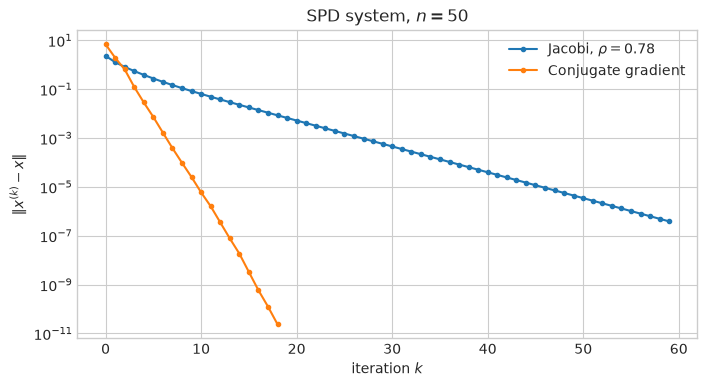

In [2]:
import matplotlib.pyplot as plt

from ml.linalg import condition_number
from ml.linear_models import ridge
from ml.optimization import conjugate_gradient

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

n = 50
M = rng.normal(size=(n, n))
A_spd = M @ M.T / n + 2 * np.eye(n)  # SPD, diagonally dominant enough for Jacobi
x_true = rng.normal(size=n)
b = A_spd @ x_true

# Jacobi
D = np.diag(A_spd)
R = A_spd - np.diag(D)
x = np.zeros(n)
err_jacobi = []
for _ in range(60):
    x = (b - R @ x) / D
    err_jacobi.append(np.linalg.norm(x - x_true))

_, path = conjugate_gradient(A_spd, b)
err_cg = np.linalg.norm(path - x_true, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(err_jacobi, ".-", label=f"Jacobi, $\\rho = {max(abs(np.linalg.eigvals(R / D[:, None]))):.2f}$")
ax.semilogy(err_cg, ".-", label="Conjugate gradient")
ax.set(xlabel="iteration $k$", ylabel=r"$\|x^{(k)} - x\|$", title=f"SPD system, $n = {n}$")
ax.legend()
plt.show()

## Ill-posedness in action: instability and regularization

When $A$ is ill-conditioned ($\kappa = \sigma_1/\sigma_n$ large), a tiny noise in $b$ explodes in $x$: with $\kappa = 10^k$ we lose about $k$ digits. Tikhonov regularization solves $(A^TA + \lambda I)x = A^Tb$, damping each SVD direction by the Wiener filter $\sigma^2/(\sigma^2 + \lambda)$.

kappa(H) = 1.8e+16


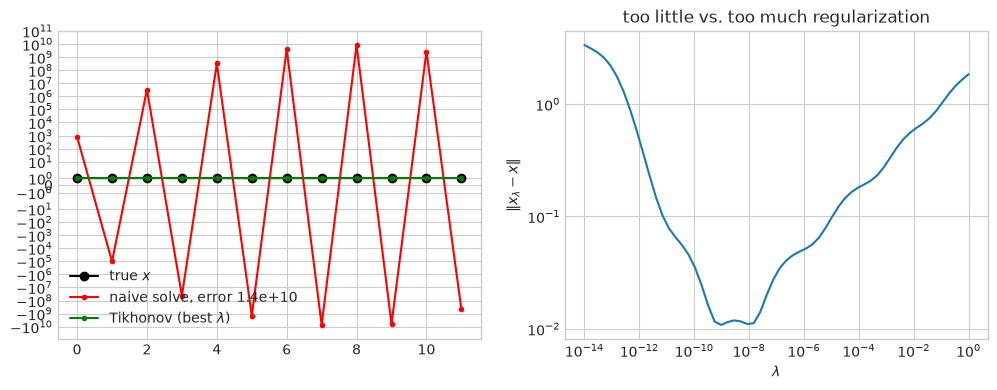

In [3]:
# Hilbert matrix: the classic ill-conditioned example
n = 12
H = 1.0 / (np.arange(n)[:, None] + np.arange(n)[None, :] + 1)
x_true = np.ones(n)
b_noisy = H @ x_true + 1e-6 * rng.normal(size=n)
print(f"kappa(H) = {condition_number(H):.1e}")

x_naive = np.linalg.solve(H, b_noisy)
lams = np.logspace(-14, 0, 60)
errs = [np.linalg.norm(ridge(H, b_noisy, lam) - x_true) for lam in lams]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(x_true, "ko-", label="true $x$")
ax1.plot(x_naive, "r.-", label=f"naive solve, error {np.linalg.norm(x_naive - x_true):.1e}")
ax1.plot(ridge(H, b_noisy, lams[np.argmin(errs)]), "g.-", label="Tikhonov (best $\\lambda$)")
ax1.set_yscale("symlog")
ax1.legend()
ax2.loglog(lams, errs)
ax2.set(xlabel=r"$\lambda$", ylabel=r"$\|x_\lambda - x\|$", title="too little vs. too much regularization")
plt.show()